# Taller 7: Fundamentos de Machine Learning y Redes Neuronales

### Sebastián Palma

### David Tobón Molina

In [56]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import cv2
import json
from tensorflow import keras
from kaggle.api.kaggle_api_extended import KaggleApi
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.metrics import F1Score
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

## 1. Preprocesamiento de Datos

### 1.1 Descarga y Preparación del Dataset

In [57]:
with open('./kaggle.json') as f:
    kaggle_credentials = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_credentials['username']
os.environ['KAGGLE_KEY'] = kaggle_credentials['key']

api = KaggleApi()
api.authenticate()
api.dataset_download_files('carlosrunner/pizza-not-pizza', path='data', unzip=True)

Dataset URL: https://www.kaggle.com/datasets/carlosrunner/pizza-not-pizza


### 1.2 Exploración de Imágenes

Imagenes de not_pizza: 983
Imagenes de pizza: 983


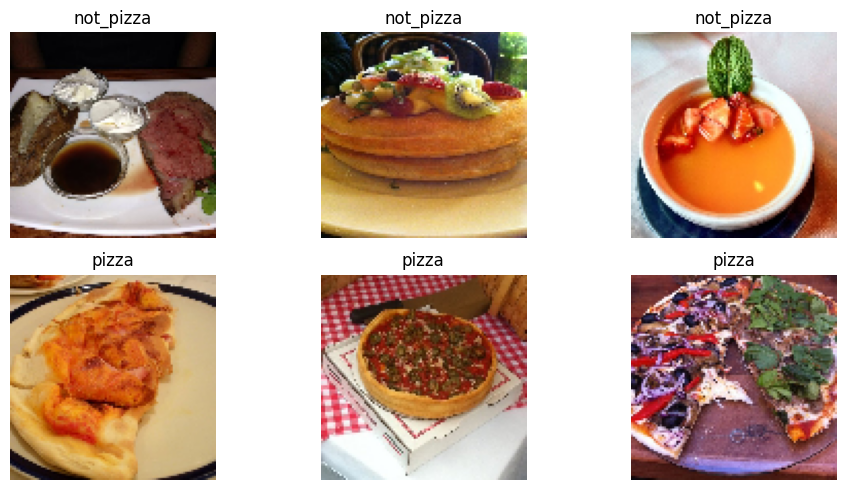

In [58]:
data_dir = 'data/pizza_not_pizza'
categories = os.listdir(data_dir)[0:-1]
categories = [d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))]

plt.figure(figsize=(10, 5))

for i, category in enumerate(categories):
    folder = os.path.join(data_dir, category)
    images = os.listdir(folder)  

    print(f"Imagenes de {category}: {len(images)}")
    
    for j, image_file in enumerate(images[:3]):
        img_path = os.path.join(folder, image_file)
        img = keras.preprocessing.image.load_img(img_path, target_size=(100, 100))
        img_array = keras.preprocessing.image.img_to_array(img) / 255.0
        plt.subplot(len(categories), 3, i*3 + j + 1)
        plt.imshow(img_array)
        plt.title(category)
        plt.axis('off')

plt.tight_layout()
plt.show()

El dataset se encuentra balanceado, cada clase tiene una prevalencia del 50% en el datset.

### 1.3 Preparación de Datos y División en Entrenamiento, Validación y Test

In [59]:
filepaths = [os.path.join(dp, f) for dp, dn, filenames in os.walk(data_dir) for f in filenames if os.path.splitext(f)[1].lower() in ['.png','.jpg','.jpeg']]
labels = [os.path.split(os.path.split(path)[0])[1] for path in filepaths]
data_df = pd.DataFrame({'filepath': filepaths, 'label': labels})

train_df, test_val_df = train_test_split(data_df, test_size=0.3, random_state=42)
test_df, val_df = train_test_split(test_val_df, test_size=2/3, random_state=42)

print("Total de imágenes:", len(data_df))
print("Entrenamiento:", len(train_df))
print("Validación:", len(val_df))
print("Test:", len(test_df))

Total de imágenes: 1966
Entrenamiento: 1376
Validación: 394
Test: 196


### 1.4 Procesamiento y Generadores de Imágenes

In [60]:
train_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    horizontal_flip=True
)

test_val_datagen = keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_dataframe(
    train_df, 
    x_col='filepath', 
    y_col='label',
    target_size=(100, 100), 
    batch_size=32
)
val_gen = test_val_datagen.flow_from_dataframe(
    val_df, 
    x_col='filepath',
    y_col='label',
    target_size=(100, 100), 
    batch_size=32, 
    shuffle=False
)
test_gen = test_val_datagen.flow_from_dataframe(
    test_df, 
    x_col='filepath', 
    y_col='label',
    target_size=(100, 100), 
    batch_size=32, 
    shuffle=False
)

Found 1376 validated image filenames belonging to 2 classes.
Found 394 validated image filenames belonging to 2 classes.
Found 196 validated image filenames belonging to 2 classes.


Las técnicas de preprocesamiento implementadas en este modelo fueron seleccionadas considerando las características del dataset Pizza vs Not Pizza:

* Normalización: Se aplicó normalización mediante la transformación de los valores de los píxeles desde el rango $ [0,255] $ al rango $ [0,1] $. Esto ya que permite que los valores de entrada se mantengan en una escala homogénea, evitando que valores grandes dominen el proceso de aprendizaje. Lo que logra una convergencia más rápida y estable durante el entrenamiento, lo cual se refleja en un comportamiento más suave de la función de pérdida.

* Data Augmentation: Se aplicaron técnicas de aumentación de datos como rotación y volteo horizontal con el fin de introducir mayor variabilidad en las imágenes de entrenamiento. Estas transformaciones permiten simular diferentes condiciones en las que podría aparecer una pizza, en diferentes posiciones y rotaciones, enriqueciendo el conjunto de datos sin necesidad de recolectar nuevas imágenes.

* Redimensionamiento de imágenes: Las imágenes fueron redimensionadas a un tamaño uniforme de 100×100 píxeles para garantizar compatibilidad con el modelo. El tamaño representa un balance adecuado entre la preservación de características relevantes y la eficiencia computacional. Lo que permite reducir disminuir el número de parámetros y el tiempo de entrenamiento sin perder información crítica para la clasificación.

## 2. Construcción de un Modelo de Red Neuronal Perceptrón Multicapa

### 2.1 Construcción y Compilación del Modelo

In [61]:
model = Sequential([
    Flatten(input_shape=(100, 100, 3)),    
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dense(len(categories), activation='softmax')
])

model.summary()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

/Users/davidtobonm/miniconda3/envs/imagenes/lib/python3.12/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_84"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_84 (Flatten)            │ (None, 30000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_252 (Dense)               │ (None, 512)            │    15,360,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_84 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_254 (Dense)               │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,492,354 (59.10 MB)

 Trainable params: 15,492,354 (59.10 MB)

 Non-trainable params: 0 (0.00 B)

La arquitectura del modelo fue diseñada para el problema de clasificación de imágenes Pizza vs Not Pizza, utilizando un perceptrón multicapa y buscando un equilibrio entre simplicidad y capacidad de aprendizaje:

1. Capa Flatten: Se encarga de transformar la imagen de entrada en un vector unidimensional. Esto permite simplificar el modelo y ayuda a capturar patrones generales en problemas de clasificación binaria como este.

2. Capa Dense: Esta capa densa proporciona al modelo una alta capacidad para aprender patrones relevantes presentes en las imágenes, con 512 neuronas. Además, se utiliza la función de activación ReLU para modelar relaciones no lineales y facilitar el entrenamiento, evitando problemas como el desvanecimiento del gradiente. El número elevado de neuronas busca capturar características iniciales de alto nivel como texturas, colores y formas generales.

3. Capa Dropout: Se incluye una capa de regularización tipo Dropout con una tasa de 0.2, lo que implica que durante el entrenamiento el 20% de las neuronas se desactiva aleatoriamente. Esto promueve que el modelo aprenda representaciones más robustas y reduce el riesgo de sobreajuste.

4. Segunda capa Dense: La segunda capa densa reduce el número de neuronas a 256, permitiendo una compresión progresiva de la información aprendida. Esta reducción actúa como un mecanismo de refinamiento, donde el modelo conserva únicamente las características más relevantes.

5. Capa de salida Dense: La capa final contiene tantas neuronas como clases en el problema y utiliza la función de activación softmax. Esta función transforma la salida del modelo en probabilidades asociadas a cada clase, facilitando la interpretación de los resultados.

## 3. Definición de Funciones de Callbacks para Monitorear el Entrenamiento

### 3.1 Entrenamiento del Modelo

In [62]:
model_checkpoint = ModelCheckpoint('best_model.h5', save_best_only=True, monitor='val_loss', mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=5, verbose=1, mode='min')
callbacks = [model_checkpoint, early_stopping, reduce_lr]

# Entrenamiento
with tf.device('/device:GPU:0'):
    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=50,
        callbacks=callbacks
    )

Epoch 1/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.5137 - loss: 7.7758

43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - accuracy: 0.5356 - loss: 4.4154 - val_accuracy: 0.5051 - val_loss: 1.7205 - learning_rate: 0.0010
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.5817 - loss: 1.6213

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.5618 - loss: 1.5637 - val_accuracy: 0.6345 - val_loss: 0.7118 - learning_rate: 0.0010
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.5808 - loss: 0.9287

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.5756 - loss: 0.8647 - val_accuracy: 0.6142 - val_loss: 0.6562 - learning_rate: 0.0010
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5863 - loss: 0.7917

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.5843 - loss: 0.8147 - val_accuracy: 0.6447 - val_loss: 0.6285 - learning_rate: 0.0010
Epoch 5/50
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.6353 - loss: 0.6832

...

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7122 - loss: 0.5543 - val_accuracy: 0.7081 - val_loss: 0.5789 - learning_rate: 1.0000e-05
Epoch 37/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7042 - loss: 0.5712

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 51ms/step - accuracy: 0.7289 - loss: 0.5590 - val_accuracy: 0.7056 - val_loss: 0.5784 - learning_rate: 1.0000e-05
Epoch 38/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7389 - loss: 0.5487

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7209 - loss: 0.5599 - val_accuracy: 0.7056 - val_loss: 0.5776 - learning_rate: 1.0000e-05
Epoch 39/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7371 - loss: 0.5458

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.7209 - loss: 0.5623 - val_accuracy: 0.7056 - val_loss: 0.5771 - learning_rate: 1.0000e-05
Epoch 40/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7122 - loss: 0.5663 - val_accuracy: 0.7030 - val_loss: 0.5777 - learning_rate: 1.0000e-05
Epoch 41/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7429 - loss: 0.5419

43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.7260 - loss: 0.5577 - val_accuracy: 0.6980 - val_loss: 0.5762 - learning_rate: 1.0000e-05
Epoch 42/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7202 - loss: 0.5607 - val_accuracy: 0.7107 - val_loss: 0.5782 - learning_rate: 1.0000e-05
Epoch 43/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7311 - loss: 0.5518 - val_accuracy: 0.7030 - val_loss: 0.5772 - learning_rate: 1.0000e-05
Epoch 44/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.7326 - loss: 0.5611 - val_accuracy: 0.7030 - val_loss: 0.5786 - learning_rate: 1.0000e-05
Epoch 45/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7202 - loss: 0.5599 - val_accuracy: 0.7132 - val_loss: 0.5792 - learning_rate: 1.0000e-05
Epoch 46/50
42/43 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7092 - loss: 0.5723
Epoch 46: ReduceLROnPlateau reducing learning rate to 1.0000000656873453e-06.
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.7086 - loss: 0

Las funciones de callbacks implementadas en este modelo fueron seleccionadas con el objetivo de monitorear y optimizar el proceso de entrenamiento:

* ModelCheckpoint: Permite guardar automáticamente el modelo que presenta el mejor desempeño durante el entrenamiento, utilizando como criterio la minimización de la pérdida en el conjunto de validación (val_loss). Esto garantiza que, independientemente del comportamiento del modelo en épocas posteriores, se conserve la mejor versión obtenida. 

* EarlyStopping:Se encarga de detener el entrenamiento cuando la pérdida de validación deja de mejorar durante un número determinado de épocas. Esto permite evitar el sobreentrenamiento del modelo, reduciendo el riesgo de sobreajuste y optimizando el tiempo de cómputo. Además, mediante el parámetro restore_best_weights=True, se asegura que el modelo final corresponda al mejor desempeño observado durante el entrenamiento.

* ReduceLROnPlateau: Ajusta dinámicamente la tasa de aprendizaje cuando el modelo deja de mostrar mejoras en la pérdida de validación. En este caso, si no se observa mejora durante 5 épocas, la tasa de aprendizaje se reduce en un factor de 0.1. Esta estrategia permite realizar ajustes más finos en etapas avanzadas del entrenamiento, facilitando la convergencia hacia mínimos más óptimos y evitando que el modelo se estanque.

## 4. Entrenamiento y Exploración de Resultados

In [70]:
def build_model():
    num_categories = 2
    input_shape = (100, 100, 3)
    model = Sequential([
        Input(shape=input_shape),
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.2),
        Dense(256, activation='relu'),
        Dense(num_categories, activation='softmax')
    ])
    return model


def get_training_components(model, file_path, learning_rate=0.001, optimizer_name='adam', lr_factor=0.1):
    # Optimizer selection
    if optimizer_name.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'sgd':
        optimizer = SGD(learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy', F1Score(average='macro', name='f1_score')]
    )

    # Callbacks
    callbacks = [
        ModelCheckpoint(file_path, save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=10, verbose=1, mode='min'),
        ReduceLROnPlateau(monitor='val_loss', factor=lr_factor, patience=5, verbose=1, mode='min')
    ]

    return model, callbacks

In [ ]:
# red de hiperparametros
learning_rates = [1e-2, 1e-3, 1e-4]
optimizers = ['adam', 'rmsprop', 'sgd']
lr_factors = [0.1, 0.01]

results = []

os.makedirs("models", exist_ok=True)

best_model_history = None
best_f1_score = 0

for lr in learning_rates:
    for opt in optimizers:
        for lr_factor in lr_factors:
            print(f"Testing LR: {lr}, Optimizer: {opt}, LR Factor: {lr_factor}")
            
            file_path = f"models/model_lr_{lr}_opt_{opt}_lrfactor_{lr_factor}.keras"
            
            model = build_model()
            
            model, callbacks = get_training_components(
                model,
                file_path=file_path,
                learning_rate=lr, 
                optimizer_name=opt,
                lr_factor=lr_factor,
            )
            
            history = model.fit(
                train_gen,
                validation_data=val_gen,
                epochs=50,
                callbacks=callbacks,
                verbose=0
            )
            
            f1_score = max(history.history['val_f1_score'])

            if best_f1_score < f1_score:
                best_model_history = history

            results.append({
                'lr': lr,
                'optimizer': opt,
                'lr_factor': lr_factor,
                'val_accuracy': max(history.history['val_accuracy']),
                'val_f1_score': f1_score,
                'val_loss': min(history.history['val_loss'])
            })

Testing LR: 0.01, Optimizer: adam, LR Factor: 0.1

Epoch 13: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.
Testing LR: 0.01, Optimizer: adam, LR Factor: 0.01

Epoch 10: ReduceLROnPlateau reducing learning rate to 9.999999776482583e-05.

Epoch 15: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
Epoch 15: early stopping
Testing LR: 0.01, Optimizer: rmsprop, LR Factor: 0.1

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0009999999776482583.

Epoch 22: ReduceLROnPlateau reducing learning rate to 9.999999310821295e-05.

Epoch 27: ReduceLROnPlateau reducing learning rate to 9.999999019782991e-06.

Epoch 32: ReduceLROnPlateau reducing learning rate to 9.99999883788405e-07.

Epoch 37: ReduceLROnPlateau reducing learning rate to 9.99999883788405e-08.

Epoch 42: ReduceLROnPlateau reducing learning rate to 9.999998695775504e-09.

Epoch 47: ReduceLROnPlateau reducing learning rate to 9.99999905104687e-10.
Epoch 49: early stopping
Testing LR: 0.01, O

### 4.2 Selección de hiperparámetros

In [ ]:
df_results = pd.DataFrame(results)

df_results = df_results.sort_values(by='val_f1_score', ascending=False)

print("Resultados de Exploración de hiperparámetros:")
print(df_results.to_string(index=False))

Resultados de Exploración de hiperparámetros:
    lr optimizer  lr_factor  val_f1_score  val_accuracy  val_loss
0.0010       sgd       0.10      0.735979      0.736041  0.557429
0.0010       sgd       0.01      0.722705      0.723350  0.567101
0.0100       sgd       0.10      0.714677      0.715736  0.560521
0.0001   rmsprop       0.10      0.710593      0.710660  0.580953
0.0001      adam       0.10      0.707698      0.708122  0.579528
0.0001   rmsprop       0.01      0.707290      0.708122  0.583429
0.0010      adam       0.10      0.706304      0.708122  0.574084
0.0010   rmsprop       0.10      0.702353      0.703046  0.596336
0.0100      adam       0.10      0.701645      0.703046  0.582919
0.0100       sgd       0.01      0.697968      0.697970  0.581968
0.0010      adam       0.01      0.696937      0.697970  0.593857
0.0001       sgd       0.10      0.690068      0.690355  0.603643
0.0001      adam       0.01      0.681144      0.687817  0.594141
0.0100      adam       0.01   

De acuerdo con la búsqueda de hiperparámetros se seleccionan los siguientes valores:

* Tasa de aprendizaje: 0.001
* Optimizador: SGD
* Factor de reducción de la tasa de aprendizaje: 0.1

Estos fueron los que obtuvieron el menor valor en la función de pérdida (0.5574) que se busca minimizar, y los mayores valores de F1 Score (0.7360) y Accuracy (0.7360) sobre el conjunto de validación.

In [ ]:
def plot_training_history(history):
    f1_score = history.history['f1_score']
    val_f1_score = history.history['val_f1_score']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(f1_score))

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, f1_score, label='F1 Score Entrenamiento')
    plt.plot(epochs_range, val_f1_score, label='F1 Score Validación')
    plt.legend(loc='lower right')
    plt.title('F1 Score')
    plt.grid(True, linestyle='--', alpha=0.6)

    # Gráfica de Pérdida
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Pérdida Entrenamiento')
    plt.plot(epochs_range, val_loss, label='Pérdida Validación')
    plt.legend(loc='upper right')
    plt.title('Pérdida')
    plt.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()

print("Métricas durante el entrenamiento del mejor modelo:")
plot_training_history(best_model_history)

In [ ]:
best_row = df_results.iloc[0]
best_model_path = f"models/model_lr_{best_row['lr']}_opt_{best_row['optimizer']}_lrfactor_{best_row['lr_factor']}.keras"

Cargando el mejor modelo: models/model_lr_0.001_opt_sgd_lrfactor_0.1.keras


### 4.3 Evaluación del modelo seleccionado

In [ ]:
def evaluate_model(model_path, generator):
    print(f"Cargando modelo desde: {model_path}")
    model = tf.keras.models.load_model(model_path)

    generator.reset()
    predictions = model.predict(generator, verbose=1)
    
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    class_names = list(generator.class_indices.keys())

    print("\nReporte de Clasificación:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, 
                yticklabels=class_names)
    
    plt.title('Matriz de Confusión')
    plt.ylabel('Etiquetas Reales')
    plt.xlabel('Etiquetas Predichas')
    plt.show()


#### 4.3.1 Evaluación sobre el conjunto de validación

In [ ]:
evaluate_model(best_model_path, val_gen)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
              precision    recall  f1-score   support

   not_pizza       0.73      0.75      0.74       197
       pizza       0.74      0.72      0.73       197

    accuracy                           0.74       394
   macro avg       0.74      0.74      0.74       394
weighted avg       0.74      0.74      0.74       394



#### 4.3.1 Evaluación sobre el conjunto de prueba

In [ ]:
evaluate_model(best_model_path, test_gen)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
              precision    recall  f1-score   support

   not_pizza       0.72      0.71      0.72       100
       pizza       0.70      0.72      0.71        96

    accuracy                           0.71       196
   macro avg       0.71      0.71      0.71       196
weighted avg       0.71      0.71      0.71       196



### 4.4 Análisis de resultados

#### 4.4.1 Análisis sobre métricas generales

Se observa una baja discrepancia entre las métricas obtenidas sobre el conjunto de validación y el conjunto de prueba. La precisión, cobertura y F1 Score bajan de 0.74 a 0.71. Esto indica que el modelo sí generaliza más allá del conjunto de entrenamiento y validación, y que los hiperparámetros escogidos y los pesos del modelo no causan un sobreajuste a los conjuntos de entrenamiento y validación, pues sobre el conjunto de prueba el desempeño es consistente.

También se observa un balance en el desempeño del modelo para cada una de las clases, obteniendo métricas similares de precisión cobertura y F1 Score tanto para la clase de ```pizza``` como para la de ```not_pizza```.

De todos modos, la leve disminución en el rendimiento puede sugerir un grado bajo de sobreajuste, donde la generalización hacia datos totalmente nuevos es ligeramente inferior.

#### 4.4.2 Análisis por clase en el conjunto de prueba

* **not_pizza**:
    * **Precisión = 0.72**: el modelo está acertando un 72% de las veces cuando indica que una imagen no es de una pizza. El 28% restante se clasificaron erróneamente como pizzas. 
    * **Cobertura = 0.71**: de todas las imágenes que realmente no eran pizzas, el modelo identificó correctamente el 71%. Por lo que hay un 29% de imágenes que no son pizzas que el modelo clasificó erróneamente como pizzas.

* **pizza**: 
    * **Precisión = 0.70**: De las imágenes clasificadas como pizzas el 70% eran pizzas reales, el otro 30% son los falsos positivos.
    * **Cobertura = 0.72**: El modelo clasificó correctamente al 72% de las pizzas reales. El otro 28% son las pizzas reales que indentificó como ```not_pizza```, los falsos negativos.

### 4.5 Propuesta de mejoras

La principal mejora para el modelo se puede aplicar a su metodología de entrenamiento. Se puede aplicar un validación cruzada, y en lugar de confiar en una única y fija división del dataset, dividir los datos en K grupos y entrenar el modelo K veces, usando cada grupo como conjunto de validación una vez. Esto permite estimar el rendimiento de manera más fiable y ayuda a prevenir el sobreajuste, pues el modelo se valida en diferentes conjuntos de datos y no se acostumbra a un único conjunto de entrenamiento y de validación.

También se puede incrementar la aplicación de aumentación de datos, aplicando zooms, voltear las imágenes en el eje vertical, y cambios de brillo, los cuales no se aplican en el actual preprocesamiento. Esta aumentación de datos crea un dataset con mayor variación en las imágenes y ayudar al modelo a generalizar mejor.

Probar con una grilla de parámetros ma2s amplia puede aumentar el desempeño, al encontrar combinaciones que mejoren aún más el desempeño.

Por último, también se puede buscar optimizar la arquitectura del modelo, ajustando el dropout, el número de capas o las dimensiones de estas. Como solo se exploró una sola arquitectura, puede que refinarla sea ideal para encontrar un modelo que generalice mejor al conjunto de datos y logre capturar relaciones y características más complejas y reveladoras que la arquitectura actual no permita.